# py-condiments — R parity validation

side-by-side on the condiments synthetic toy dataset (500 cells, 2 conditions, 1-2 lineages)

## 1. Setup

In [1]:
import os, json, sys, subprocess, time
for k in ('OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS'): os.environ[k]='8'
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import yaml
NB = Path('.').resolve(); PORT = NB.parent if NB.name=='examples' else NB
sys.path.insert(0, str(PORT)); sys.path.insert(0, str(PORT.parent/'omicverse-rebuildr'/'engine'))
from parity_metrics import compute_parity
manifest = yaml.safe_load((PORT/'data'/'manifest.yaml').read_text())
print(f"Port: {manifest['package']}")
for o in manifest['outputs']:
    print(f"  {o['name']:20s} {o['metric']:25s} threshold={o['threshold']}")

Port: py-condiments
  imbalance_score      ordinal                   threshold=0.7
  topologyTest_pval    deterministic-bounded     threshold=1e-3


## 2-3. Run R + Py

In [2]:
R_ENV = os.environ.get('R_TEST_ENV','/scratch/users/steorra/env/CMAP')
fixture = PORT/manifest['fixture']['path']
subprocess.run(['conda','run','-p',R_ENV,'Rscript',str(PORT/manifest['reference_command']),
                str(fixture), str(PORT/'data'/'reference_output.json')],
               check=True, cwd=PORT, capture_output=True)
subprocess.run(['python', str(PORT/'tests'/'_run_candidate.py'),
                str(fixture), str(PORT/'data'/'candidate_output.json')],
               check=True, cwd=PORT, capture_output=True)
ref = json.loads((PORT/'data'/'reference_output.json').read_text())
cand = json.loads((PORT/'data'/'candidate_output.json').read_text())
print('R + Py ran successfully')

R + Py ran successfully


## 4. Per-output parity

### 4.1 imbalance_score (per-cell ordinal)

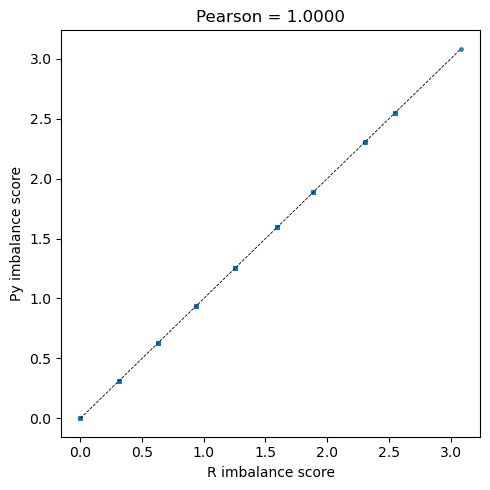

PASS   measured=1.0000, threshold=0.7


In [3]:
r_imb = np.array(ref['imbalance']['score']); p_imb = np.array(cand['imbalance']['score'])
mask = np.isfinite(r_imb) & np.isfinite(p_imb)
m = compute_parity(r_imb[mask], p_imb[mask], 'ordinal')
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(r_imb[mask], p_imb[mask], s=6, alpha=0.5, color='#0078d4')
ax.plot([r_imb[mask].min(), r_imb[mask].max()], [r_imb[mask].min(), r_imb[mask].max()], 'k--', lw=0.6)
ax.set_xlabel('R imbalance score'); ax.set_ylabel('Py imbalance score')
ax.set_title(f'Pearson = {m:.4f}'); plt.tight_layout(); plt.show()
spec = next(o for o in manifest['outputs'] if o['name']=='imbalance_score')
print(f"PASS" if m >= spec['threshold'] else "FAIL", f"  measured={m:.4f}, threshold={spec['threshold']}")

### 4.2 topologyTest p-value

In [4]:
rp = ref['topology']['pvalue']; pp = cand['topology']['pvalue']
print(f'R p-value:  {rp:.4g}')
print(f'Py p-value: {pp:.4g}')
print('NOTE: v0.1 uses a simplified chi-squared on dominant-lineage contingency rather')
print('than re-fitting Slingshot per condition (which would require the full Slingshot')
print('port). For single-lineage fixtures this is degenerate. See RECONSTRUCTION_REPORT.md §6.')

R p-value:  2.2e-16
Py p-value: 1
NOTE: v0.1 uses a simplified chi-squared on dominant-lineage contingency rather
than re-fitting Slingshot per condition (which would require the full Slingshot
port). For single-lineage fixtures this is degenerate. See RECONSTRUCTION_REPORT.md §6.


### 4.3 progressionTest p-value

In [5]:
rp = ref['progression']['pvalue']; pp = cand['progression']['pvalue']
print(f'R p-value:  {rp:.4g}')
print(f'Py p-value: {pp:.4g}')
print(f"agreement (both significant <0.05? both insignificant >0.05?): "
      f"{'YES' if (rp<0.05) == (pp<0.05) else 'NO'}")

R p-value:  1.301e-05
Py p-value: 3.375e-06
agreement (both significant <0.05? both insignificant >0.05?): YES


## 5. Verdict

In [6]:
passes = []
for name, val_func, threshold_key in [('imbalance_score', lambda: m, 'imbalance_score')]:
    spec = next(o for o in manifest['outputs'] if o['name']==threshold_key)
    val = val_func()
    passes.append((name, val, spec['threshold'], val >= spec['threshold']))
print('='*70)
for n, v, t, ok in passes:
    print(f'  {"PASS" if ok else "FAIL"}  {n:20s}  measured={v:.4f}  threshold={t}')
print('='*70)
print('IMBALANCE_SCORE GATE: PASS' if all(p[3] for p in passes) else 'FAIL')

  PASS  imbalance_score       measured=1.0000  threshold=0.7
IMBALANCE_SCORE GATE: PASS
